# Códigos completos para generar los gráficos del Word - EPS 2025

Ejecuta las celdas en orden. Primero sube los 2 Excel originales. El notebook genera y muestra los 5 gráficos usados en el Word, además de guardar las imágenes en la carpeta `graficos_word`.


In [3]:
# ============================================================
# CELDA 1: Instalar e importar librerías
# ============================================================
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata
import os
import glob
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Carpeta donde se guardarán los gráficos del Word
os.makedirs('graficos_word', exist_ok=True)

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


In [4]:
import os

# ============================================================
# CELDA 2: Subir los dos archivos Excel al Colab
# ============================================================
# Sube estos dos archivos:
# 1) Data emisiones EPS ene23-dic25 (1)(1).xlsx
# 2) Data siniestros EPS ene25-dic25 (2)(2).xlsx

# Los archivos ya están presentes en el entorno de Colab.
# La subida interactiva se omite para evitar el error 'TypeError: 'NoneType' object is not subscriptable'
# La siguiente celda detectará los archivos automáticamente.


In [7]:
# ============================================================
# CELDA 3: Detectar automáticamente los archivos subidos
# ============================================================
archivos_excel = glob.glob('*.xlsx')
print('Excel encontrados en Colab:')
for a in archivos_excel:
    print('-', a)

archivo_emisiones = None
archivo_siniestros = None

for a in archivos_excel:
    nombre = a.lower()
    if 'emisiones' in nombre:
        archivo_emisiones = a
    if 'siniestros' in nombre:
        archivo_siniestros = a

if archivo_emisiones is None or archivo_siniestros is None:
    raise FileNotFoundError('No se detectaron correctamente los Excel. Verifica que los nombres contengan emisiones y siniestros.')

print('Archivo emisiones:', archivo_emisiones)
print('Archivo siniestros:', archivo_siniestros)


Excel encontrados en Colab:
- Data siniestros EPS ene25-dic25 (2).xlsx
- Data emisiones EPS ene23-dic25 (1).xlsx
Archivo emisiones: Data emisiones EPS ene23-dic25 (1).xlsx
Archivo siniestros: Data siniestros EPS ene25-dic25 (2).xlsx


In [10]:
# ============================================================
# CELDA 4: Leer las hojas necesarias de cada Excel
# ============================================================
# Emisiones: hoja Data Base
# Siniestros: hoja EPS_2025

cols_emisiones = [
    'anio', 'mes', 'ccliente', 'cliente', 'contrato', 'finicio', 'broker', 'pcomi',
    'prima_sin_igv', 'com', 'prima_igv', 'afil', 'grupo', 'admin', 'emision',
    'Calidad datos Primas', 'Calidad datos Afiliados'
]

cols_siniestros = [
    'des_cliente', 'imp_gp_c_igv', 'gastos_presentados', 'imp_pagar_afiliado',
    'bnfcio', 'edad', 'dbnfco', 'provincia_proveedor', 'indicador_cg',
    'tipo_contrato', 'q_consultas', 'dias_int', 'aniomes_liquidacion'
]

# Revisar hojas disponibles
print('Hojas emisiones:', pd.ExcelFile(archivo_emisiones).sheet_names)
print('Hojas siniestros:', pd.ExcelFile(archivo_siniestros).sheet_names)

em = pd.read_excel(archivo_emisiones, sheet_name='Data Base', usecols=cols_emisiones)
sin = pd.read_excel(archivo_siniestros, sheet_name='EPS_2025', usecols=cols_siniestros)

print('Dimensión emisiones:', em.shape)
print('Dimensión siniestros:', sin.shape)

display(em.head())
display(sin.head())


Hojas emisiones: ['Data Base']
Hojas siniestros: ['EPS_2025', 'Hoja1']
Dimensión emisiones: (35197, 17)
Dimensión siniestros: (317144, 13)


,anio,mes,ccliente,cliente,contrato,finicio,broker,pcomi,prima_sin_igv,com,prima_igv,afil,grupo,admin,emision,Calidad datos Primas,Calidad datos Afiliados
0,24,1,119752,INNOVATION CLEVERLY S.A.C.,1676972,2024-01-01,OCHOA LOAYZA FATIMA ANALI,0.05,551.88,27.6,651.21,3,NaN,LFERPRI,IRIOSI,1.0,1.0
1,24,2,119752,INNOVATION CLEVERLY S.A.C.,1676972,2024-01-01,OCHOA LOAYZA FATIMA ANALI,0.05,551.88,27.6,651.21,3,NaN,LFERPRI,IRIOSI,1.0,1.0
2,24,3,119752,INNOVATION CLEVERLY S.A.C.,1676972,2024-01-01,OCHOA LOAYZA FATIMA ANALI,0.05,0.00,0.0,0.00,3,NaN,LFERPRI,IRIOSI,0.0,1.0
3,24,4,119752,INNOVATION CLEVERLY S.A.C.,1676972,2024-01-01,OCHOA LOAYZA FATIMA ANALI,0.05,551.88,27.6,651.21,3,NaN,LFERPRI,IRIOSI,1.0,1.0
4,24,5,119752,INNOVATION CLEVERLY S.A.C.,1676972,2024-01-01,OCHOA LOAYZA FATIMA ANALI,0.05,551.88,27.6,651.21,3,NaN,LFERPRI,IRIOSI,1.0,1.0


,des_cliente,imp_gp_c_igv,gastos_presentados,imp_pagar_afiliado,dbnfco,bnfcio,provincia_proveedor,indicador_cg,edad,tipo_contrato,q_consultas,dias_int,aniomes_liquidacion
0,MAQUINARIAS Y EQUIPOS DEL PERU S.A.,139.14,117.92,0.0,CONSULTA AMBULATORIA,111.32,LIMA,S,55.0,2.0,0,0,202506.0
1,T & V CONSULTING AND ENGINEERING E.I.R.L.,778.80,660.00,0.0,CONSULTA AMBULATORIA,584.10,LIMA,S,33.0,1.0,0,0,202509.0
2,RTS AUTOMATION S.A.C,385.08,326.34,0.0,CONSULTA AMBULATORIA,288.82,LIMA,S,9.0,2.0,0,0,202502.0
3,ECOSAC AGRICOLA S.A.C.,792.99,672.03,0.0,CONSULTA AMBULATORIA,634.39,LIMA,S,41.0,2.0,0,0,202504.0
4,VOESTALPINE HIGH PERFORMANCE METALS DEL PERU S.A.,61.95,52.50,0.0,CONTROL DEL NIÃƒÂ‘O SANO,61.95,LIMA,N,1.0,1.0,1,0,202508.0


In [11]:
# ============================================================
# CELDA 5: Funciones de limpieza y normalización
# ============================================================

def normalizar_cliente(x):
    # Convierte nombres de clientes a una forma estándar para poder unir emisiones y siniestros.
    if pd.isna(x):
        return ''
    x = str(x).upper().strip()
    x = ''.join(c for c in unicodedata.normalize('NFD', x) if unicodedata.category(c) != 'Mn')
    x = re.sub(r'[^A-Z0-9 ]+', ' ', x)
    x = re.sub(r'(S A C|SAC|S A|SA|S R L|SRL|E I R L|EIRL|S A A|SAA)', '', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x


def moda_texto(s):
    # Devuelve el valor de texto más frecuente. Se usa para variables categóricas agrupadas.
    s = s.dropna().astype(str)
    if len(s) == 0:
        return ''
    m = s.mode()
    return m.iloc[0] if not m.empty else ''


def limpiar_numero(serie):
    # Convierte una serie a número y reemplaza valores no convertibles por cero.
    return pd.to_numeric(serie, errors='coerce').fillna(0)

print('Funciones creadas correctamente.')


Funciones creadas correctamente.


In [12]:
# ============================================================
# CELDA 6: Limpieza inicial, filtro 2025 y control de duplicados
# ============================================================
# Solo se trabaja con el año 2025.

# Filtro 2025 en emisiones. El archivo puede traer anio como 25 o 2025.
em['anio_num'] = pd.to_numeric(em['anio'], errors='coerce')
em25 = em[em['anio_num'].isin([25, 2025])].copy()

# Normalización de clientes para hacer el cruce
em25['cliente_norm'] = em25['cliente'].apply(normalizar_cliente)
sin['cliente_norm'] = sin['des_cliente'].apply(normalizar_cliente)

# Convertir variables numéricas de emisiones
for col in ['prima_igv', 'prima_sin_igv', 'com', 'afil', 'pcomi']:
    em25[col] = limpiar_numero(em25[col])

# Convertir variables numéricas de siniestros
for col in ['imp_gp_c_igv', 'gastos_presentados', 'imp_pagar_afiliado', 'bnfcio',
            'edad', 'q_consultas', 'dias_int', 'aniomes_liquidacion']:
    sin[col] = limpiar_numero(sin[col])

# Control de duplicados exactos
duplicados_emisiones = em25.duplicated().sum()
duplicados_siniestros = sin.duplicated().sum()

print('Registros de emisiones 2025:', len(em25))
print('Registros de siniestros 2025:', len(sin))
print('Duplicados exactos en emisiones 2025:', duplicados_emisiones)
print('Duplicados exactos en siniestros 2025:', duplicados_siniestros)

# Tabla de control para mostrar como evidencia
tabla_control = pd.DataFrame({
    'Base': ['Emisiones 2025', 'Siniestros 2025'],
    'Registros': [len(em25), len(sin)],
    'Duplicados exactos': [duplicados_emisiones, duplicados_siniestros],
    'Clientes normalizados únicos': [em25['cliente_norm'].nunique(), sin['cliente_norm'].nunique()]
})
display(tabla_control)

Registros de emisiones 2025: 12196
Registros de siniestros 2025: 317144
Duplicados exactos en emisiones 2025: 0
Duplicados exactos en siniestros 2025: 13401


,Base,Registros,Duplicados exactos,Clientes normalizados únicos
0,Emisiones 2025,12196,0,1375
1,Siniestros 2025,317144,13401,1278


In [13]:
# ============================================================
# CELDA 7: Crear variables de mes para los gráficos mensuales
# ============================================================
# En emisiones el mes ya viene como 1, 2, 3... 12.
em25['mes'] = pd.to_numeric(em25['mes'], errors='coerce').astype('Int64')

# En siniestros aniomes_liquidacion suele venir como 202501, 202502, etc.
sin['aniomes_liquidacion'] = pd.to_numeric(sin['aniomes_liquidacion'], errors='coerce')
sin['mes_liquidacion_2025'] = (sin['aniomes_liquidacion'] % 100).astype('Int64')

# Mantener solo meses válidos 1 a 12 para gráficos
em25 = em25[em25['mes'].between(1, 12)].copy()
sin = sin[sin['mes_liquidacion_2025'].between(1, 12)].copy()

print('Meses disponibles en emisiones:', sorted(em25['mes'].dropna().unique()))
print('Meses disponibles en siniestros:', sorted(sin['mes_liquidacion_2025'].dropna().unique()))

Meses disponibles en emisiones: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Meses disponibles en siniestros: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]


In [14]:
# ============================================================
# CELDA 8: Agregación de emisiones por cuenta-cliente
# ============================================================
# Esta tabla consolida primas, afiliados, contratos y variables de negocio por cliente.

em_agg = em25.groupby('cliente_norm').agg(
    cliente=('cliente', 'first'),
    ccliente=('ccliente', 'first'),
    n_contratos=('contrato', 'nunique'),
    meses_emitidos=('mes', 'nunique'),
    prima_igv_2025=('prima_igv', 'sum'),
    prima_sin_igv_2025=('prima_sin_igv', 'sum'),
    comision_2025=('com', 'sum'),
    afil_mes_suma_2025=('afil', 'sum'),
    afil_prom_2025=('afil', 'mean'),
    afil_max_2025=('afil', 'max'),
    pcomi_prom_2025=('pcomi', 'mean'),
    broker_top=('broker', moda_texto),
    admin_top=('admin', moda_texto),
    emision_top=('emision', moda_texto),
    calidad_primas_prom=('Calidad datos Primas', 'mean'),
    calidad_afiliados_prom=('Calidad datos Afiliados', 'mean')
).reset_index()

# Variables de enero a junio para que el modelo prediga alta siniestralidad anual sin usar toda la información futura.
em_jun = em25[em25['mes'].between(1, 6)].groupby('cliente_norm').agg(
    meses_emitidos_jun=('mes', 'nunique'),
    prima_igv_jun=('prima_igv', 'sum'),
    prima_sin_igv_jun=('prima_sin_igv', 'sum'),
    comision_jun=('com', 'sum'),
    afil_mes_suma_jun=('afil', 'sum'),
    afil_prom_jun=('afil', 'mean'),
    afil_max_jun=('afil', 'max'),
    pcomi_prom_jun=('pcomi', 'mean')
).reset_index()

em_agg = em_agg.merge(em_jun, on='cliente_norm', how='left').fillna(0)

print('Tabla emisiones agregada:', em_agg.shape)
display(em_agg.head())

Tabla emisiones agregada: (1375, 25)


,cliente_norm,cliente,ccliente,n_contratos,meses_emitidos,prima_igv_2025,prima_sin_igv_2025,comision_2025,afil_mes_suma_2025,afil_prom_2025,...,calidad_primas_prom,calidad_afiliados_prom,meses_emitidos_jun,prima_igv_jun,prima_sin_igv_jun,comision_jun,afil_mes_suma_jun,afil_prom_jun,afil_max_jun,pcomi_prom_jun
0,3420 WEALTH MANAGEMENT LOCAL MARKET S A C,3420 WEALTH MANAGEMENT LOCAL MARKET S.A.C.,333415,1,12,66498.06,56354.30,2817.72,148,12.333333,...,1.0,1.0,6.0,29075.67,24640.40,1232.02,65.0,10.833333,12.0,0.05
1,A M AUDITORES Y CONSULTORES JURIDICOS S A C,A & M AUDITORES Y CONSULTORES JURIDICOS S.A.C.,216652,1,12,8620.96,7305.88,365.32,24,2.000000,...,1.0,1.0,6.0,4121.58,3492.84,174.66,12.0,2.000000,2.0,0.05
2,A Y C FRANK CONSTRUCTORES S A C,A Y C FRANK CONSTRUCTORES S.A.C,362143,1,3,546.27,462.93,37.02,3,1.000000,...,1.0,1.0,0.0,0.00,0.00,0.00,0.0,0.000000,0.0,0.00
3,A Y F CONSTRUCTORES S A C,A Y F CONSTRUCTORES S.A.C.,267193,1,4,4359.48,3694.48,295.56,16,4.000000,...,1.0,1.0,0.0,0.00,0.00,0.00,0.0,0.000000,0.0,0.00
4,AARN OUTSOURCING EMPRESARIAL S A C,AARN OUTSOURCING EMPRESARIAL S.A.C.,364778,1,8,3473.12,2943.36,147.20,16,2.000000,...,1.0,1.0,6.0,2604.84,2207.52,110.40,12.0,2.000000,2.0,0.05


In [15]:
# ============================================================
# CELDA 9: Agregación de siniestros por cuenta-cliente
# ============================================================
# Se crean indicadores de uso y tipo de atención.

sin['ambulatorio'] = sin['dbnfco'].astype(str).str.upper().str.contains('AMB|CONSULTA', regex=True).astype(int)
sin['hospitalario'] = ((sin['dbnfco'].astype(str).str.upper().str.contains('HOSP|HOS', regex=True)) | (sin['dias_int'] > 0)).astype(int)
sin['maternidad'] = sin['dbnfco'].astype(str).str.upper().str.contains('MAT|MATERN', regex=True).astype(int)
sin['cg_s'] = (sin['indicador_cg'].astype(str).str.upper() == 'S').astype(int)

sin_agg = sin.groupby('cliente_norm').agg(
    siniestros_2025=('imp_gp_c_igv', 'sum'),
    gastos_presentados_2025=('gastos_presentados', 'sum'),
    n_siniestros_2025=('imp_gp_c_igv', 'count'),
    beneficio_2025=('bnfcio', 'sum'),
    q_consultas_2025=('q_consultas', 'sum'),
    dias_int_2025=('dias_int', 'sum'),
    edad_prom_2025=('edad', 'mean'),
    cobertura_top=('dbnfco', moda_texto),
    provincia_top=('provincia_proveedor', moda_texto),
    tipo_contrato_top=('tipo_contrato', moda_texto)
).reset_index()

# Variables de enero a junio para los predictores del modelo.
sin_jun = sin[sin['mes_liquidacion_2025'].between(1, 6)].groupby('cliente_norm').agg(
    siniestros_jun=('imp_gp_c_igv', 'sum'),
    gastos_presentados_jun=('gastos_presentados', 'sum'),
    n_siniestros_jun=('imp_gp_c_igv', 'count'),
    beneficio_jun=('bnfcio', 'sum'),
    q_consultas_jun=('q_consultas', 'sum'),
    dias_int_jun=('dias_int', 'sum'),
    edad_prom_jun=('edad', 'mean'),
    ambulatorio_jun=('ambulatorio', 'sum'),
    hospitalario_jun=('hospitalario', 'sum'),
    maternidad_jun=('maternidad', 'sum'),
    pct_cg_s_jun=('cg_s', 'mean')
).reset_index()

sin_agg = sin_agg.merge(sin_jun, on='cliente_norm', how='left').fillna(0)

print('Tabla siniestros agregada:', sin_agg.shape)
display(sin_agg.head())

Tabla siniestros agregada: (1211, 22)


,cliente_norm,siniestros_2025,gastos_presentados_2025,n_siniestros_2025,beneficio_2025,q_consultas_2025,dias_int_2025,edad_prom_2025,cobertura_top,provincia_top,...,gastos_presentados_jun,n_siniestros_jun,beneficio_jun,q_consultas_jun,dias_int_jun,edad_prom_jun,ambulatorio_jun,hospitalario_jun,maternidad_jun,pct_cg_s_jun
0,3420 WEALTH MANAGEMENT LOCAL MARKET S A C,117902.25,99917.26,205,103159.67,139,9,50.473171,CONSULTA AMBULATORIA,LIMA,...,41801.92,108.0,43166.99,68.0,0.0,51.462963,60.0,0.0,0.0,0.861111
1,A JAIME ROJAS REPRESENTACIONES GRLES S A,380.40,322.38,3,380.39,1,0,20.333333,CONSULTA AMBULATORIA,LIMA,...,97.80,1.0,115.39,0.0,0.0,26.000000,1.0,0.0,0.0,0.000000
2,A M AUDITORES Y CONSULTORES JURIDICOS S A C,2638.33,2235.87,7,1967.51,5,0,55.857143,CONSULTA AMBULATORIA,LIMA,...,1133.38,4.0,988.80,2.0,0.0,55.500000,4.0,0.0,0.0,1.000000
3,A Y C FRANK CONSTRUCTORES S A C,2397.88,2032.10,2,2095.74,3,3,21.000000,CONSULTA AMBULATORIA,CAJAMARCA,...,0.00,0.0,0.00,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
4,A Y F CONSTRUCTORES S A C,154.94,131.31,1,131.70,0,0,12.000000,CONSULTA AMBULATORIA,CAJAMARCA,...,0.00,0.0,0.00,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000


In [16]:
# ============================================================
# CELDA 10: Construcción del dataset final y variable objetivo
# ============================================================
# Target: 1 si la cuenta-cliente tiene siniestralidad anual >= 82%, 0 en caso contrario.

df = em_agg.merge(sin_agg, on='cliente_norm', how='left').fillna(0)

# Retirar cuentas con prima anual no positiva para evitar divisiones inválidas.
df = df[df['prima_igv_2025'] > 0].copy()

# Variable objetivo anual 2025
df['siniestralidad_2025'] = df['siniestros_2025'] / df['prima_igv_2025']
df['target_alta_siniestralidad'] = (df['siniestralidad_2025'] >= 0.82).astype(int)

# Variables predictoras construidas con información de enero a junio.
df['siniestralidad_jun'] = np.where(df['prima_igv_jun'] > 0, df['siniestros_jun'] / df['prima_igv_jun'], 0)
df['frecuencia_jun'] = np.where(df['afil_mes_suma_jun'] > 0, df['n_siniestros_jun'] / df['afil_mes_suma_jun'], 0)
df['severidad_jun'] = np.where(df['n_siniestros_jun'] > 0, df['siniestros_jun'] / df['n_siniestros_jun'], 0)
df['prima_percapita_jun'] = np.where(df['afil_mes_suma_jun'] > 0, df['prima_igv_jun'] / df['afil_mes_suma_jun'], 0)
df['pct_ambulatorio_jun'] = np.where(df['n_siniestros_jun'] > 0, df['ambulatorio_jun'] / df['n_siniestros_jun'], 0)
df['pct_hospitalario_jun'] = np.where(df['n_siniestros_jun'] > 0, df['hospitalario_jun'] / df['n_siniestros_jun'], 0)
df['pct_maternidad_jun'] = np.where(df['n_siniestros_jun'] > 0, df['maternidad_jun'] / df['n_siniestros_jun'], 0)

print('Dataset final:', df.shape)
print('\nDistribución del target:')
print(df['target_alta_siniestralidad'].value_counts())
print('\nPorcentaje del target:')
print((df['target_alta_siniestralidad'].value_counts(normalize=True) * 100).round(2))

display(df.head())

Dataset final: (1277, 55)

Distribución del target:
target_alta_siniestralidad
0    818
1    459
Name: count, dtype: int64

Porcentaje del target:
target_alta_siniestralidad
0    64.06
1    35.94
Name: proportion, dtype: float64


,cliente_norm,cliente,ccliente,n_contratos,meses_emitidos,prima_igv_2025,prima_sin_igv_2025,comision_2025,afil_mes_suma_2025,afil_prom_2025,...,pct_cg_s_jun,siniestralidad_2025,target_alta_siniestralidad,siniestralidad_jun,frecuencia_jun,severidad_jun,prima_percapita_jun,pct_ambulatorio_jun,pct_hospitalario_jun,pct_maternidad_jun
0,3420 WEALTH MANAGEMENT LOCAL MARKET S A C,3420 WEALTH MANAGEMENT LOCAL MARKET S.A.C.,333415,1,12,66498.06,56354.30,2817.72,148,12.333333,...,0.861111,1.773018,1,1.696477,1.661538,456.724074,447.318,0.555556,0.0,0.0
1,A M AUDITORES Y CONSULTORES JURIDICOS S A C,A & M AUDITORES Y CONSULTORES JURIDICOS S.A.C.,216652,1,12,8620.96,7305.88,365.32,24,2.000000,...,1.000000,0.306037,0,0.324485,0.333333,334.347500,343.465,1.000000,0.0,0.0
2,A Y C FRANK CONSTRUCTORES S A C,A Y C FRANK CONSTRUCTORES S.A.C,362143,1,3,546.27,462.93,37.02,3,1.000000,...,0.000000,4.389551,1,0.000000,0.000000,0.000000,0.000,0.000000,0.0,0.0
3,A Y F CONSTRUCTORES S A C,A Y F CONSTRUCTORES S.A.C.,267193,1,4,4359.48,3694.48,295.56,16,4.000000,...,0.000000,0.035541,0,0.000000,0.000000,0.000000,0.000,0.000000,0.0,0.0
4,AARN OUTSOURCING EMPRESARIAL S A C,AARN OUTSOURCING EMPRESARIAL S.A.C.,364778,1,8,3473.12,2943.36,147.20,16,2.000000,...,0.791667,1.704686,1,2.102724,2.000000,228.219167,217.070,0.791667,0.0,0.0


In [17]:
# ============================================================
# CELDA 11: Tabla de análisis descriptivo por target
# ============================================================
eda_target = df.groupby('target_alta_siniestralidad').agg(
    cuentas=('cliente_norm', 'count'),
    prima_promedio=('prima_igv_2025', 'mean'),
    siniestros_promedio=('siniestros_2025', 'mean'),
    siniestralidad_promedio=('siniestralidad_2025', 'mean'),
    siniestralidad_jun_promedio=('siniestralidad_jun', 'mean'),
    frecuencia_jun_promedio=('frecuencia_jun', 'mean'),
    severidad_jun_promedio=('severidad_jun', 'mean'),
    edad_promedio_jun=('edad_prom_jun', 'mean')
).reset_index()

eda_target['grupo'] = eda_target['target_alta_siniestralidad'].map({0: 'No alta (<82%)', 1: 'Alta (>=82%)'})
display(eda_target)

,target_alta_siniestralidad,cuentas,prima_promedio,siniestros_promedio,siniestralidad_promedio,siniestralidad_jun_promedio,frecuencia_jun_promedio,severidad_jun_promedio,edad_promedio_jun,grupo
0,0,818,91474.876112,48031.256760,0.322342,0.29710,0.317251,250.906642,23.761773,No alta (<82%)
1,1,459,151368.279281,181440.298998,1.973889,1.62858,0.954534,599.725242,38.881327,Alta (>=82%)


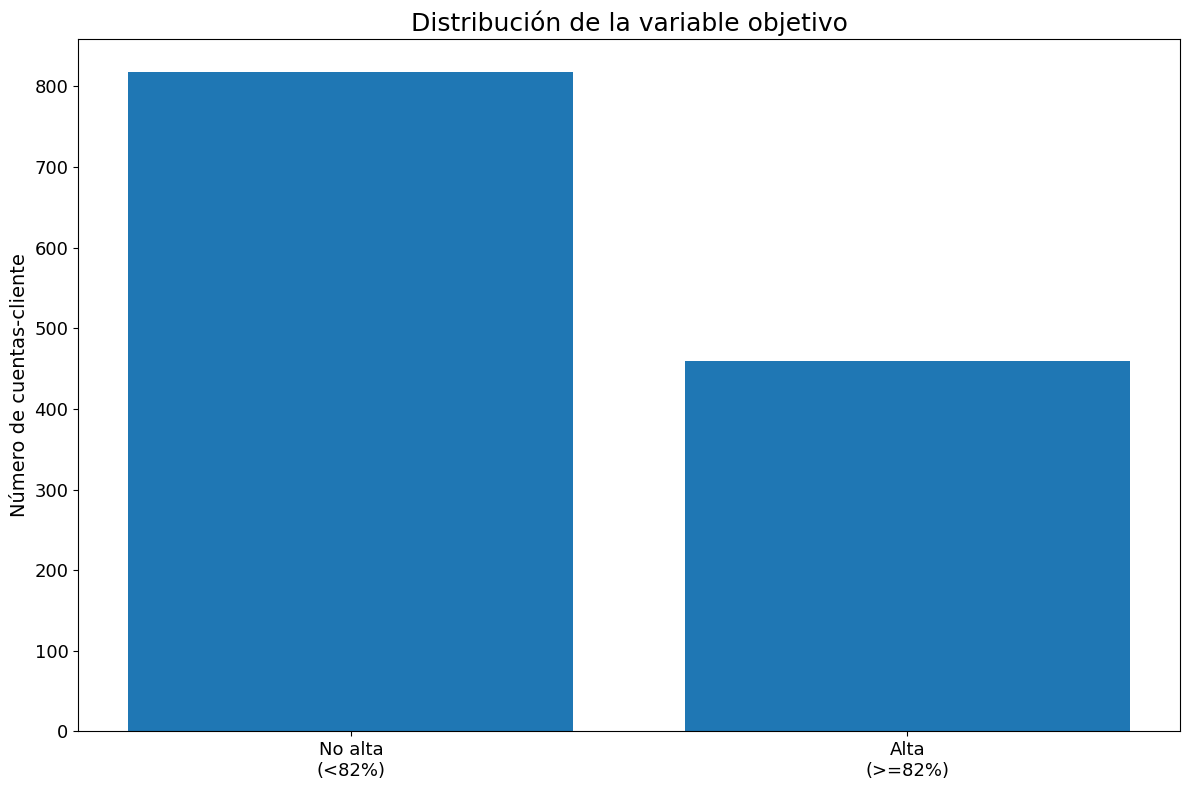

Gráfico guardado en: graficos_word/fig1_distribucion_target.png


In [18]:
# ============================================================
# CELDA 12: GRÁFICO 1 - Distribución de la variable objetivo
# ============================================================
conteo_target = df['target_alta_siniestralidad'].value_counts().sort_index()
conteo_target.index = ['No alta\n(<82%)', 'Alta\n(>=82%)']

plt.figure(figsize=(12, 8))
plt.bar(conteo_target.index, conteo_target.values)
plt.title('Distribución de la variable objetivo', fontsize=18)
plt.ylabel('Número de cuentas-cliente', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.savefig('graficos_word/fig1_distribucion_target.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico guardado en: graficos_word/fig1_distribucion_target.png')

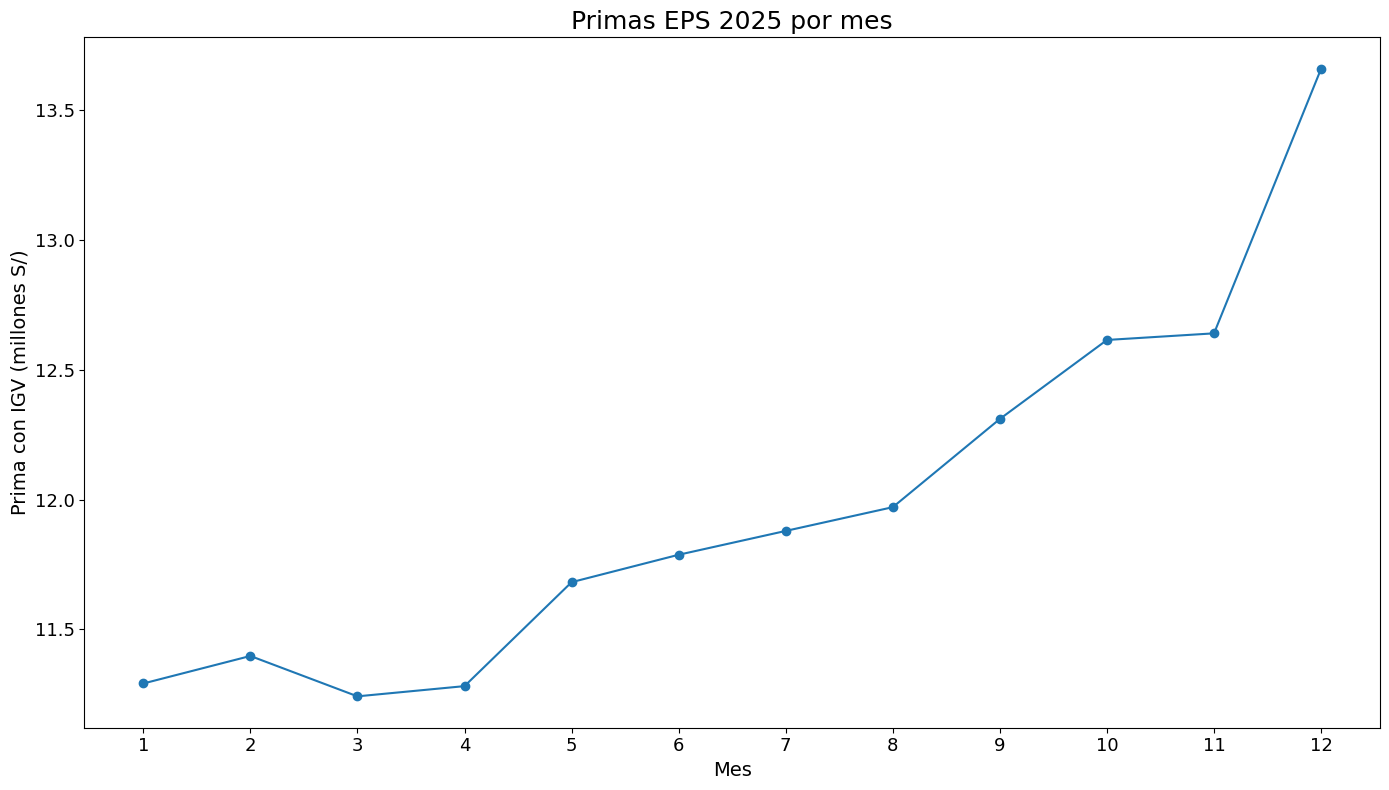

Gráfico guardado en: graficos_word/fig2_primas_siniestros_mes.png


,Mes,Prima IGV millones S/
0,1,11.291946
1,2,11.397846
2,3,11.242463
3,4,11.281779
4,5,11.681877
5,6,11.787435
6,7,11.879171
7,8,11.970621
8,9,12.310200
9,10,12.614205


In [19]:
# ============================================================
# CELDA 13: GRÁFICO 2 - Primas EPS 2025 por mes
# ============================================================
primas_mes = em25.groupby('mes')['prima_igv'].sum().reindex(range(1, 13), fill_value=0) / 1_000_000

plt.figure(figsize=(14, 8))
plt.plot(primas_mes.index, primas_mes.values, marker='o')
plt.title('Primas EPS 2025 por mes', fontsize=18)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Prima con IGV (millones S/)', fontsize=14)
plt.xticks(range(1, 13), fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.savefig('graficos_word/fig2_primas_siniestros_mes.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico guardado en: graficos_word/fig2_primas_siniestros_mes.png')
display(primas_mes.reset_index().rename(columns={'mes': 'Mes', 'prima_igv': 'Prima IGV millones S/'}))

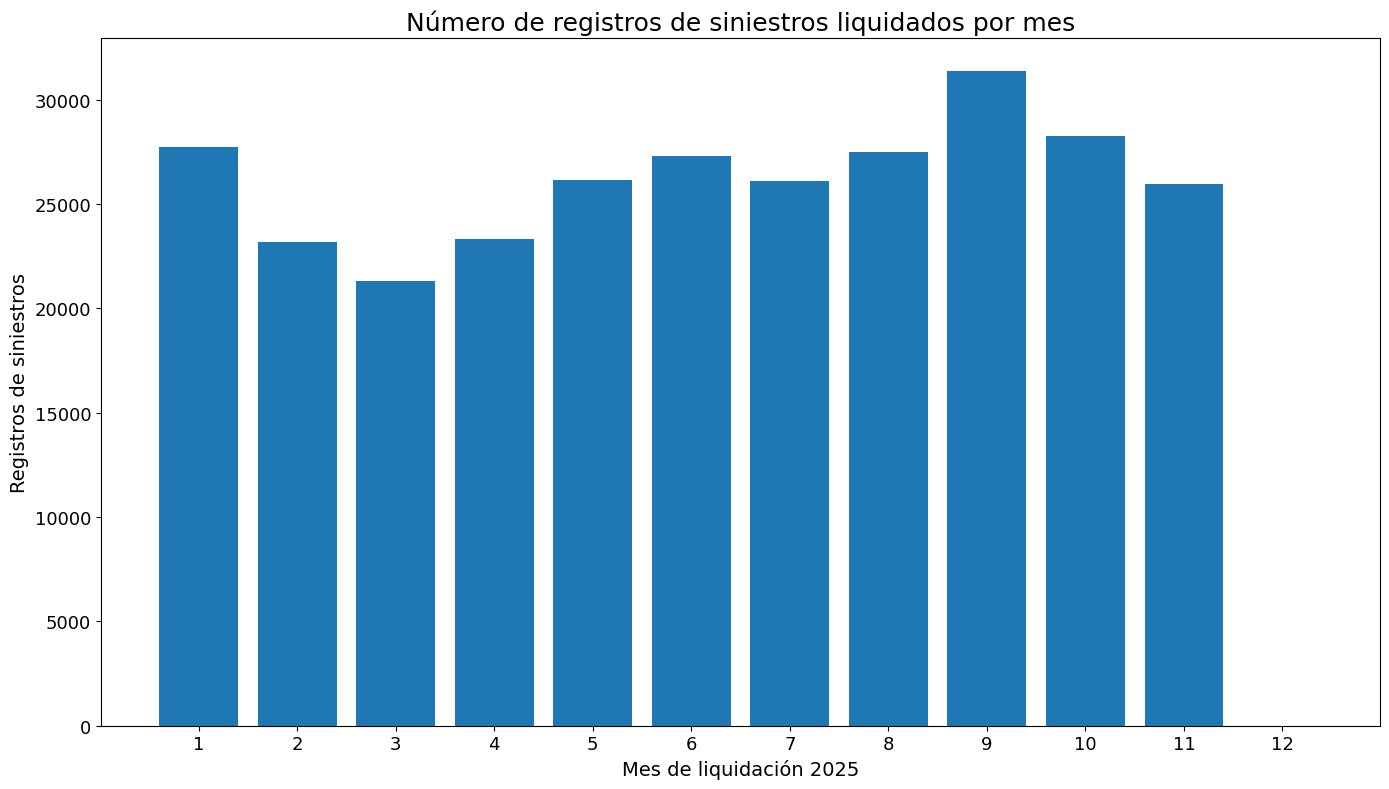

Gráfico guardado en: graficos_word/fig3_siniestros_count_mes.png


,Mes,Registros de siniestros
0,1,27733
1,2,23202
2,3,21316
3,4,23305
4,5,26144
5,6,27296
6,7,26098
7,8,27486
8,9,31396
9,10,28273


In [20]:
# ============================================================
# CELDA 14: GRÁFICO 3 - Número de registros de siniestros liquidados por mes
# ============================================================
siniestros_mes = sin.groupby('mes_liquidacion_2025').size().reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(14, 8))
plt.bar(siniestros_mes.index, siniestros_mes.values)
plt.title('Número de registros de siniestros liquidados por mes', fontsize=18)
plt.xlabel('Mes de liquidación 2025', fontsize=14)
plt.ylabel('Registros de siniestros', fontsize=14)
plt.xticks(range(1, 13), fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.savefig('graficos_word/fig3_siniestros_count_mes.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico guardado en: graficos_word/fig3_siniestros_count_mes.png')
display(siniestros_mes.reset_index().rename(columns={'mes_liquidacion_2025': 'Mes', 0: 'Registros de siniestros'}))

In [21]:
# ============================================================
# CELDA 15: Preparar variables para el modelo de clasificación
# ============================================================
# No se usan identificadores, nombres ni códigos como variables predictoras.
# Se usan variables de enero a junio para predecir el resultado anual 2025.

numeric_features = [
    'n_contratos', 'meses_emitidos_jun', 'prima_igv_jun', 'prima_sin_igv_jun', 'comision_jun',
    'afil_mes_suma_jun', 'afil_prom_jun', 'afil_max_jun', 'pcomi_prom_jun',
    'n_siniestros_jun', 'siniestros_jun', 'gastos_presentados_jun', 'beneficio_jun',
    'q_consultas_jun', 'dias_int_jun', 'edad_prom_jun', 'siniestralidad_jun',
    'frecuencia_jun', 'severidad_jun', 'prima_percapita_jun',
    'pct_cg_s_jun', 'pct_ambulatorio_jun', 'pct_hospitalario_jun', 'pct_maternidad_jun',
    'calidad_primas_prom', 'calidad_afiliados_prom'
]

categorical_features = [
    'broker_top', 'admin_top', 'emision_top', 'tipo_contrato_top', 'provincia_top', 'cobertura_top'
]

# Verificar que las columnas existan
faltantes = [c for c in numeric_features + categorical_features if c not in df.columns]
if faltantes:
    raise ValueError('Faltan columnas en el dataset: ' + str(faltantes))

X = df[numeric_features + categorical_features].copy()
y = df['target_alta_siniestralidad'].copy()

print('X:', X.shape)
print('y:', y.shape)
print('Variables numéricas:', len(numeric_features))
print('Variables categóricas:', len(categorical_features))

X: (1277, 32)
y: (1277,)
Variables numéricas: 26
Variables categóricas: 6


In [23]:
# ============================================================
# CELDA 16: Entrenar Árbol de Decisión y Regresión Logística
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Convert categorical features to string type to avoid TypeError with OneHotEncoder
for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# Para variables categóricas: imputación + one-hot encoding.
# min_frequency reduce categorías poco frecuentes para evitar demasiadas columnas.
cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=10))
])

preprocess_tree = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', cat_pipe, categorical_features)
])

preprocess_log = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', cat_pipe, categorical_features)
])

arbol = Pipeline(steps=[
    ('preprocess', preprocess_tree),
    ('model', DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42
    ))
])

logistica = Pipeline(steps=[
    ('preprocess', preprocess_log),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

modelos = {
    'Árbol de Decisión': arbol,
    'Regresión Logística': logistica
}

resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    prob = modelo.predict_proba(X_test)[:, 1]

    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, prob),
        'Matriz_confusion': confusion_matrix(y_test, pred)
    })

metricas = pd.DataFrame(resultados)
display(metricas.drop(columns=['Matriz_confusion']))

print('Matriz de confusión - Árbol de Decisión:')
print(metricas.loc[metricas['Modelo'] == 'Árbol de Decisión', 'Matriz_confusion'].iloc[0])

print('\nMatriz de confusión - Regresión Logística:')
print(metricas.loc[metricas['Modelo'] == 'Regresión Logística', 'Matriz_confusion'].iloc[0])

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,Árbol de Decisión,0.87500,0.921348,0.713043,0.803922,0.893489
1,Regresión Logística,0.85625,0.834951,0.747826,0.788991,0.907487


Matriz de confusión - Árbol de Decisión:
[[198   7]
 [ 33  82]]

Matriz de confusión - Regresión Logística:
[[188  17]
 [ 29  86]]


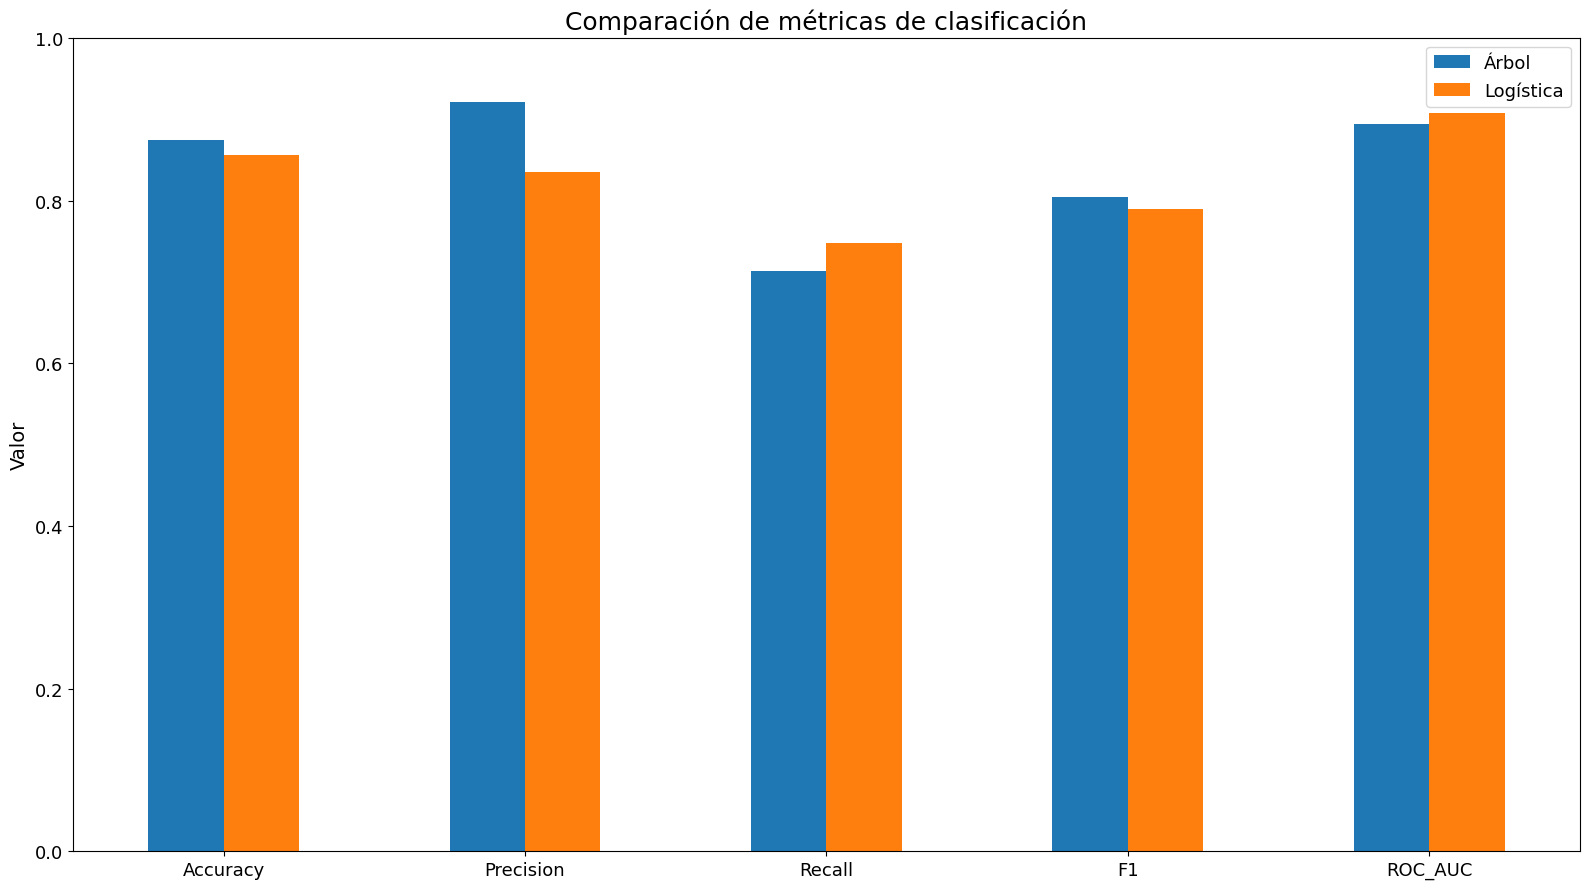

Gráfico guardado en: graficos_word/fig4_metricas_modelos.png


In [24]:
# ============================================================
# CELDA 17: GRÁFICO 4 - Comparación de métricas de clasificación
# ============================================================
metricas_graf = metricas.drop(columns=['Matriz_confusion']).copy()
metricas_graf['Modelo'] = metricas_graf['Modelo'].replace({
    'Árbol de Decisión': 'Árbol',
    'Regresión Logística': 'Logística'
})

metricas_plot = metricas_graf.set_index('Modelo')[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].T

plt.figure(figsize=(16, 9))
metricas_plot.plot(kind='bar', ax=plt.gca())
plt.title('Comparación de métricas de clasificación', fontsize=18)
plt.ylabel('Valor', fontsize=14)
plt.ylim(0, 1)
plt.xticks(rotation=0, fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig('graficos_word/fig4_metricas_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico guardado en: graficos_word/fig4_metricas_modelos.png')

In [25]:
# ============================================================
# CELDA 18: Calcular importancia de variables del Árbol de Decisión
# ============================================================
arbol_entrenado = modelos['Árbol de Decisión']

feature_names = arbol_entrenado.named_steps['preprocess'].get_feature_names_out()
importancias = arbol_entrenado.named_steps['model'].feature_importances_

imp_detalle = pd.DataFrame({
    'variable_transformada': feature_names,
    'importancia': importancias
})

# Función para agrupar variables transformadas a su variable original.
# Ejemplo: cat__cobertura_top_XXX se agrupa como cobertura_top.
def variable_original(nombre):
    nombre = str(nombre)
    if nombre.startswith('num__'):
        return nombre.replace('num__', '')
    if nombre.startswith('cat__'):
        sin_prefijo = nombre.replace('cat__', '')
        for col in categorical_features:
            if sin_prefijo.startswith(col + '_') or sin_prefijo == col:
                return col
        return sin_prefijo
    return nombre

imp_detalle['variable_original'] = imp_detalle['variable_transformada'].apply(variable_original)

imp = imp_detalle.groupby('variable_original', as_index=False)['importancia'].sum()
imp = imp.sort_values('importancia', ascending=False)

# Nombres más legibles para el gráfico
dic_nombres = {
    'siniestralidad_jun': 'siniestralidad jun',
    'comision_jun': 'comision jun',
    'cobertura_top': 'cobertura top',
    'n_siniestros_jun': 'n siniestros jun',
    'prima_percapita_jun': 'prima percapita jun',
    'severidad_jun': 'severidad jun',
    'pct_hospitalario_jun': 'pct hospitalario jun',
    'frecuencia_jun': 'frecuencia jun',
    'prima_igv_jun': 'prima igv jun',
    'dias_int_jun': 'dias int jun'
}
imp['variable_grafico'] = imp['variable_original'].replace(dic_nombres)

display(imp.head(15))

,variable_original,importancia,variable_grafico
29,siniestralidad_jun,0.879325,siniestralidad jun
31,tipo_contrato_top,0.037854,tipo_contrato_top
5,broker_top,0.033156,broker_top
25,prima_sin_igv_jun,0.022390,prima_sin_igv_jun
13,frecuencia_jun,0.014423,frecuencia jun
11,edad_prom_jun,0.012040,edad_prom_jun
24,prima_percapita_jun,0.000812,prima percapita jun
0,admin_top,0.000000,admin_top
7,calidad_primas_prom,0.000000,calidad_primas_prom
6,calidad_afiliados_prom,0.000000,calidad_afiliados_prom


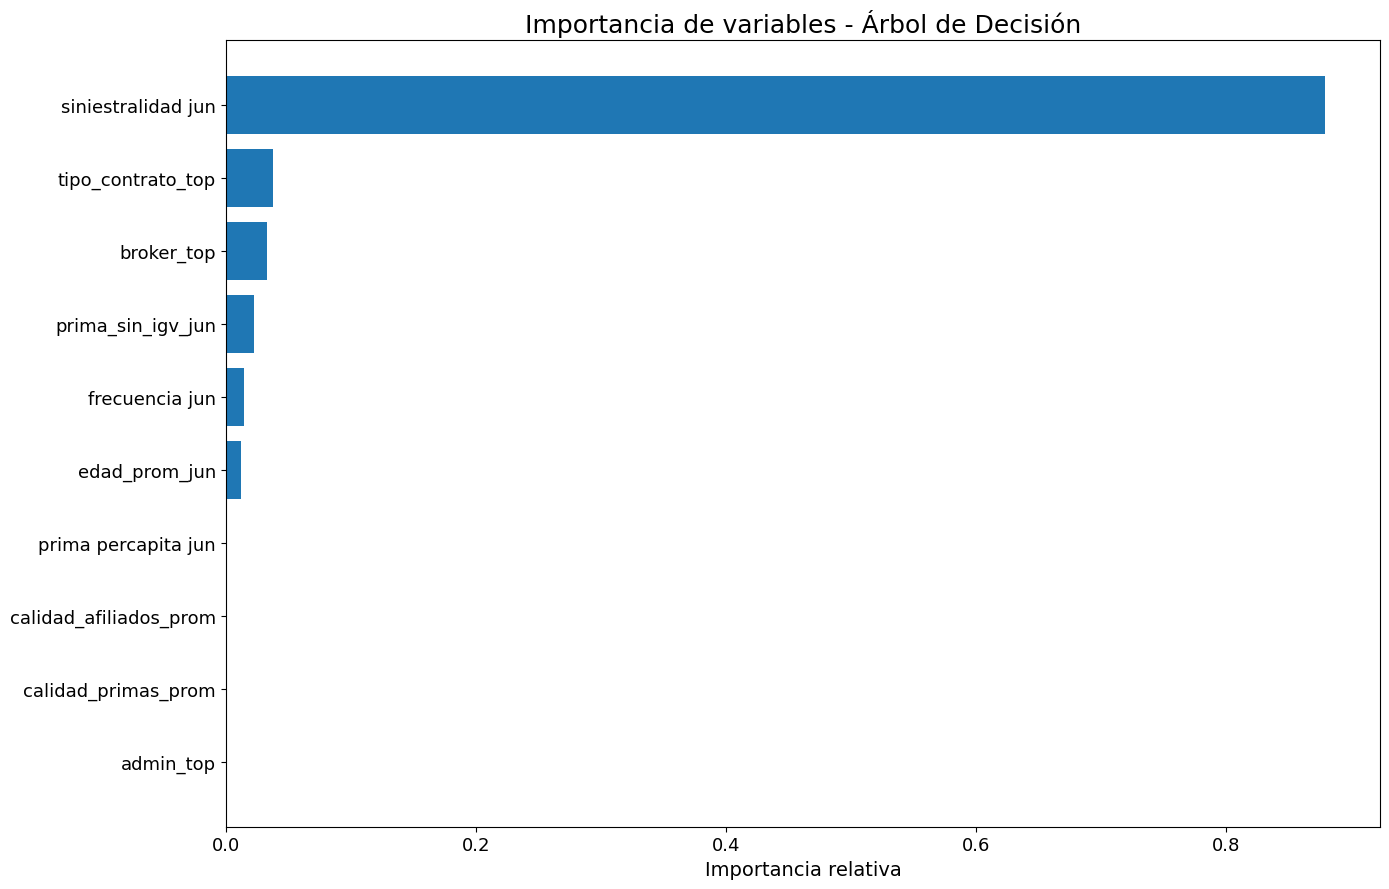

Gráfico guardado en: graficos_word/fig5_importancia_variables.png


In [26]:
# ============================================================
# CELDA 19: GRÁFICO 5 - Importancia de variables del Árbol de Decisión
# ============================================================
top_imp = imp.head(10).sort_values('importancia', ascending=True)

plt.figure(figsize=(14, 9))
plt.barh(top_imp['variable_grafico'], top_imp['importancia'])
plt.title('Importancia de variables - Árbol de Decisión', fontsize=18)
plt.xlabel('Importancia relativa', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.savefig('graficos_word/fig5_importancia_variables.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico guardado en: graficos_word/fig5_importancia_variables.png')

In [27]:
# ============================================================
# CELDA 20: Exportar dataset, métricas y gráficos en ZIP
# ============================================================
df.to_csv('dataset_modelo_eps_2025.csv', index=False, encoding='utf-8-sig')
metricas.drop(columns=['Matriz_confusion']).to_csv('metricas_modelos_eps_2025.csv', index=False, encoding='utf-8-sig')
imp.to_csv('importancia_variables_arbol.csv', index=False, encoding='utf-8-sig')

!zip -r graficos_word_eps_2025.zip graficos_word dataset_modelo_eps_2025.csv metricas_modelos_eps_2025.csv importancia_variables_arbol.csv

print('Archivos generados:')
print('- dataset_modelo_eps_2025.csv')
print('- metricas_modelos_eps_2025.csv')
print('- importancia_variables_arbol.csv')
print('- graficos_word_eps_2025.zip')

# Para descargar automáticamente el ZIP, descomenta la siguiente línea:
# files.download('graficos_word_eps_2025.zip')


  adding: graficos_word/ (stored 0%)
  adding: graficos_word/fig4_metricas_modelos.png (deflated 44%)
  adding: graficos_word/fig3_siniestros_count_mes.png (deflated 35%)
  adding: graficos_word/fig1_distribucion_target.png (deflated 35%)
  adding: graficos_word/fig5_importancia_variables.png (deflated 35%)
  adding: graficos_word/fig2_primas_siniestros_mes.png (deflated 26%)
  adding: dataset_modelo_eps_2025.csv (deflated 68%)
  adding: metricas_modelos_eps_2025.csv (deflated 21%)
  adding: importancia_variables_arbol.csv (deflated 63%)
Archivos generados:
- dataset_modelo_eps_2025.csv
- metricas_modelos_eps_2025.csv
- importancia_variables_arbol.csv
- graficos_word_eps_2025.zip
